# Figure 3 — Nested-CV comparison on healthy vs BRCA+CRC (Cristiano cohort)

**Panels** — (a) mean ROC over the 10 outer test folds for the data-driven model
and the ATAC, RNA and ichorCNA baselines; (b) classification metrics at the
fold-specific 95%-specificity operating point (threshold derived on each
training fold); (c) paired per-sample posterior differences relative to the
data-driven model, by class (Healthy + Stage I–IV), with one-sided Wilcoxon
signed-rank tests.

**Source data** (this notebook reads nothing else — no result pickles, no
cluster paths, no network):
- `data/fig3_predictions.csv` — one row per (method, sample): out-of-fold
  prediction score, outer-fold id, label, fold-specific train-derived
  95%-specificity threshold, stage/disease annotation. ichorCNA rows cover
  every sample in the ichorCNA table (fold = NA outside the BRCA/CRC task);
  `n_rows_in_source` records the row multiplicity of the original table so
  the computation matches the original analysis exactly.
- `data/fig3_config.csv` — the selected model configuration per method.

Both files are written by `export/export_fig3.py`, which validates the
exported scores against the stored pipeline results. Run this notebook top
to bottom from `src/figures/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, auc

APPROACH_COLORS = {
    "RNA": "#CA3542",        # crimson
    "ATAC": "#ECB22E",       # gold/amber
    "Data-driven": "#0173B2",  # deep blue
    "ichorCNA": "#6A3D9A",   # purple
}
METHOD_LABELS = {"data_driven": "Data-driven", "atac": "ATAC", "rna": "RNA", "ichorcna": "ichorCNA"}
STAGES = ["I", "II", "III", "IV"]

In [2]:
pred = pd.read_csv("data/fig3_predictions.csv")
config = pd.read_csv("data/fig3_config.csv")
display(config)

task = pred[pred["method"] == "data_driven"]
print(f"task samples: {task['sample_id'].nunique()} "
      f"({(task['y_true'] == 0).sum()} healthy, {(task['y_true'] == 1).sum()} cancer), "
      f"folds: {task['fold'].nunique()}")
ichor_all = pred[pred["method"] == "ichorcna"]
print(f"ichorCNA rows: {len(ichor_all)} samples "
      f"({int(ichor_all['fold'].notna().sum())} inside the task folds)")

,method,feature,classifier,weighting_function,top_genes,source_dir,selection_mean_auc
0,data_driven,griffin_diff,Support Vector Machine,mean_diff,14224.0,nested_cv_results_cris/brca_crc_dd,0.950595
1,rna,rcov,Multi-Layer Perceptron,NaN,NaN,nested_cv_results_cris/brca_crc_rna,0.680357
2,atac,ulz_atac_tfbs_features,Support Vector Machine,NaN,NaN,nested_cv_results_cris/brca_crc_atac,0.912798
3,ichorcna,ichorcna_tf,NaN,NaN,NaN,accessory_files/cris_stage_vaf_coverage_ichor_...,NaN


task samples: 290 (210 healthy, 80 cancer), folds: 10
ichorCNA rows: 534 samples (290 inside the task folds)


## Helpers

The ichorCNA arm mirrors the original analysis: per outer fold, the
95%-specificity threshold is derived from all samples **not** in that fold's
test set (the whole ichorCNA table, other cancer types included), and the
fold's test samples are then scored against it. `n_rows_in_source` repeats
rows that were duplicated in the original table.

In [3]:
def expand(df):
    """Repeat rows by their multiplicity in the original ichorCNA table."""
    return df.loc[df.index.repeat(df["n_rows_in_source"])]


def fold_rocs(df):
    """Per-fold ROC curves and AUCs from out-of-fold scores."""
    out = []
    for _, g in df.groupby("fold"):
        g = expand(g).dropna(subset=["score"])
        fpr, tpr, _ = roc_curve(g["y_true"], g["score"])
        out.append((fpr, tpr, auc(fpr, tpr)))
    return out


def ichor_fold_threshold(fold):
    """95%-specificity threshold from the ichorCNA 'training' split of a fold."""
    train = ichor_all[(ichor_all["fold"] != fold) | ichor_all["fold"].isna()]
    train = expand(train).dropna(subset=["score"])
    fpr_tr, tpr_tr, thr_tr = roc_curve(train["y_true"], train["score"])
    idx = np.where(1 - fpr_tr >= 0.95)[0]
    return thr_tr[idx[-1]]


def binary_metrics(y, y_hat):
    tn = int(np.sum((y == 0) & (y_hat == 0)))
    fp = int(np.sum((y == 0) & (y_hat == 1)))
    fn = int(np.sum((y == 1) & (y_hat == 0)))
    tp = int(np.sum((y == 1) & (y_hat == 1)))
    m = {
        "recall": tp / (tp + fn) if tp + fn else 0.0,
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "specificity": tn / (tn + fp) if tn + fp else 0.0,
    }
    # Precision/F1 are undefined when a fold makes no positive predictions
    # (TP+FP == 0); those folds are skipped for precision/F1 only.
    if tp + fp:
        m["precision"] = tp / (tp + fp)
        m["f1-score"] = 2 * m["precision"] * m["recall"] / (m["precision"] + m["recall"]) \
            if (m["precision"] + m["recall"]) else 0.0
    return m


def collect_fold_metrics(method):
    """Per-fold metrics at the fold's 95%-specificity threshold."""
    df = pred[pred["method"] == method]
    folds = sorted(df["fold"].dropna().unique())
    per_fold = []
    for f in folds:
        g = expand(df[df["fold"] == f]).dropna(subset=["score"])
        thr = ichor_fold_threshold(f) if method == "ichorcna" else g["threshold_95spec"].iloc[0]
        per_fold.append(binary_metrics(g["y_true"].to_numpy(), (g["score"] >= thr).to_numpy().astype(int)))
    keys = ["precision", "recall", "f1-score", "accuracy", "specificity"]
    return {k: [m[k] for m in per_fold if k in m] for k in keys}

## Panel a — mean ROC over the outer folds

In [4]:
def panel_a(ax):
    base_fpr = np.linspace(0, 1, 101)
    for method in ["data_driven", "atac", "rna", "ichorcna"]:
        name = METHOD_LABELS[method]
        color = APPROACH_COLORS[name]
        df = pred[(pred["method"] == method) & pred["fold"].notna()]
        tprs, aucs = [], []
        for fpr, tpr, a in fold_rocs(df):
            tprs.append(interp1d(fpr, tpr, kind="linear")(base_fpr))
            aucs.append(a)
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[0], mean_tpr[-1] = 0, 1
        std_tpr = np.std(tprs, axis=0)
        ax.plot(base_fpr, mean_tpr, color=color, linewidth=2.3,
                label=f"{name} — AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
        ax.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0),
                        np.minimum(mean_tpr + std_tpr, 1), color=color, alpha=0.2)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1.2)
    ax.axvline(x=0.05, color="dimgray", linestyle=":", linewidth=1.6, alpha=0.85,
               zorder=1, label="95% specificity (FPR = 0.05)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("False Positive Rate", fontsize=15)
    ax.set_ylabel("True Positive Rate", fontsize=15)
    ax.legend(loc="lower right", fontsize=10.5, frameon=True)
    ax.tick_params(labelsize=12)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

## Panel b — metrics at the 95%-specificity operating point

Error bars are the standard error of the mean over the 10 outer folds
(`error_type="sem"` in the original notebook), clipped so bars stay in [0, 1].

In [5]:
def panel_b(ax, approach_metrics, error_type="sem"):
    metric_names = ["Precision", "Sensitivity\n(Recall)", "F1-Score", "Accuracy", "Specificity"]
    metric_keys = ["precision", "recall", "f1-score", "accuracy", "specificity"]
    x = np.arange(len(metric_names))
    width = 0.2
    order = [("data_driven", "Data-driven"), ("atac", "ATAC"),
             ("rna", "RNA"), ("ichorcna", "ichorCNA")]
    for idx, (method, label) in enumerate(order):
        m = approach_metrics[method]
        means = [np.mean(m[k]) if m[k] else 0 for k in metric_keys]
        if error_type == "sem":
            errs = [np.std(m[k], ddof=1) / np.sqrt(len(m[k])) if len(m[k]) > 1 else 0
                    for k in metric_keys]
        else:
            errs = [np.std(m[k]) if m[k] else 0 for k in metric_keys]
        yerr_lo = [min(e, mu) for mu, e in zip(means, errs)]
        yerr_hi = [min(e, 1.0 - mu) for mu, e in zip(means, errs)]
        offset = (idx - (len(order) - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=[yerr_lo, yerr_hi], label=label,
               color=APPROACH_COLORS[label], alpha=0.85, capsize=3,
               error_kw={"elinewidth": 0.8})
        for i, v in enumerate(means):
            ax.text(i + offset, v + errs[i], f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Score", fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=14)
    ax.legend(fontsize=12, loc="upper left", ncol=2, framealpha=0.9)
    ax.set_ylim(0, 1.18)
    ax.tick_params(labelsize=15)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

## Panel c — paired posterior differences by class

For each sample the posterior of a baseline is subtracted from the
data-driven posterior (for ichorCNA the tumor fraction serves as its score).
One-sided Wilcoxon signed-rank tests, in the class-appropriate direction:
cancer stages test H1 data-driven > baseline; Healthy tests
H1 data-driven < baseline (fewer false positives).

In [6]:
def _sig_marker(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def panel_c(ax, rng_seed=0):
    in_task = pred[pred["fold"].notna()]
    prob = {}   # method -> {sample_id: score}
    for method in METHOD_LABELS:
        g = in_task[in_task["method"] == method].dropna(subset=["score"])
        prob[method] = g.drop_duplicates("sample_id").set_index("sample_id")["score"].to_dict()

    sample_info = in_task[in_task["method"] == "data_driven"] \
        .drop_duplicates("sample_id").set_index("sample_id")[["y_true", "stage"]]

    def ids_for(cat):
        if cat == "Healthy":
            return set(sample_info[sample_info["y_true"] == 0].index)
        return set(sample_info[(sample_info["y_true"] == 1) & (sample_info["stage"] == cat)].index)

    comparisons = ["ATAC", "RNA", "ichorCNA"]
    comp_methods = {"ATAC": "atac", "RNA": "rna", "ichorCNA": "ichorcna"}
    comp_colors = [APPROACH_COLORS[c] for c in comparisons]
    categories = ["Healthy"] + STAGES

    diff_records, test_results = [], {}
    for cat in categories:
        cat_ids = ids_for(cat)
        alternative = "less" if cat == "Healthy" else "greater"
        for comp in comparisons:
            comp_prob = prob[comp_methods[comp]]
            common = [s for s in cat_ids if s in prob["data_driven"] and s in comp_prob]
            diffs = np.array([prob["data_driven"][s] - comp_prob[s] for s in common])
            for s, d in zip(common, diffs):
                diff_records.append({"Category": cat, "Comparison": f"vs {comp}", "Difference": d})
            if len(diffs) >= 5 and not np.all(diffs == 0):
                _, p_dir = stats.wilcoxon(diffs, alternative=alternative)
            else:
                p_dir = np.nan
            test_results[(cat, comp)] = {"n": len(diffs), "median": np.median(diffs),
                                         "p_directional": p_dir, "alternative": alternative}
    diff_df = pd.DataFrame(diff_records)

    rng = np.random.default_rng(rng_seed)  # jitter only; fixed for reproducible layout
    n_comps = len(comparisons)
    box_width = 0.22
    cat_positions = np.arange(len(categories))
    offsets = np.linspace(-box_width * (n_comps - 1) / 2, box_width * (n_comps - 1) / 2, n_comps)

    for c_idx, comp in enumerate(comparisons):
        positions = cat_positions + offsets[c_idx]
        box_data = [diff_df[(diff_df["Category"] == cat) & (diff_df["Comparison"] == f"vs {comp}")]
                    ["Difference"].values for cat in categories]
        bp = ax.boxplot(box_data, positions=positions, widths=box_width * 0.85,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", linewidth=1.2))
        for patch in bp["boxes"]:
            patch.set_facecolor(comp_colors[c_idx])
            patch.set_alpha(0.45)
        for element in ["whiskers", "caps"]:
            for line in bp[element]:
                line.set_linewidth(0.8)
        jitter = box_width * 0.28
        for s_idx, vals in enumerate(box_data):
            if len(vals):
                x_jit = positions[s_idx] + rng.uniform(-jitter, jitter, len(vals))
                ax.scatter(x_jit, vals, s=10, color=comp_colors[c_idx], alpha=0.7,
                           edgecolors="white", linewidths=0.3, zorder=3)

    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    bracket_y_base, bracket_step = 1.04, 0.07
    for s_idx, cat in enumerate(categories):
        for c_idx, comp in enumerate(comparisons):
            p_d = test_results[(cat, comp)]["p_directional"]
            if np.isnan(p_d):
                continue
            sig = _sig_marker(p_d)
            ax.text(cat_positions[s_idx] + offsets[c_idx], bracket_y_base + c_idx * bracket_step,
                    sig, ha="center", va="bottom", fontsize=12,
                    fontweight="bold" if sig != "ns" else "normal",
                    color=comp_colors[c_idx], alpha=1.0 if sig != "ns" else 0.6)

    ax.set_xticks(cat_positions)
    ax.set_xticklabels(categories, fontsize=15)
    ax.set_ylabel("Posteriors relative to the data-driven model", fontsize=12)
    ax.set_ylim([-1.05, 1.05 + n_comps * bracket_step + 0.03])
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.5)
    ax.axvline(x=0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], marker="s", color="w", markerfacecolor=comp_colors[i],
                      markersize=8, label=f"vs {comp}", markeredgecolor="none")
               for i, comp in enumerate(comparisons)]
    ax.legend(handles=handles, fontsize=12, loc="lower right", framealpha=0.85,
              handlelength=1.0, handletextpad=0.4, borderpad=0.3, labelspacing=0.3)
    return test_results

## Assemble Figure 3

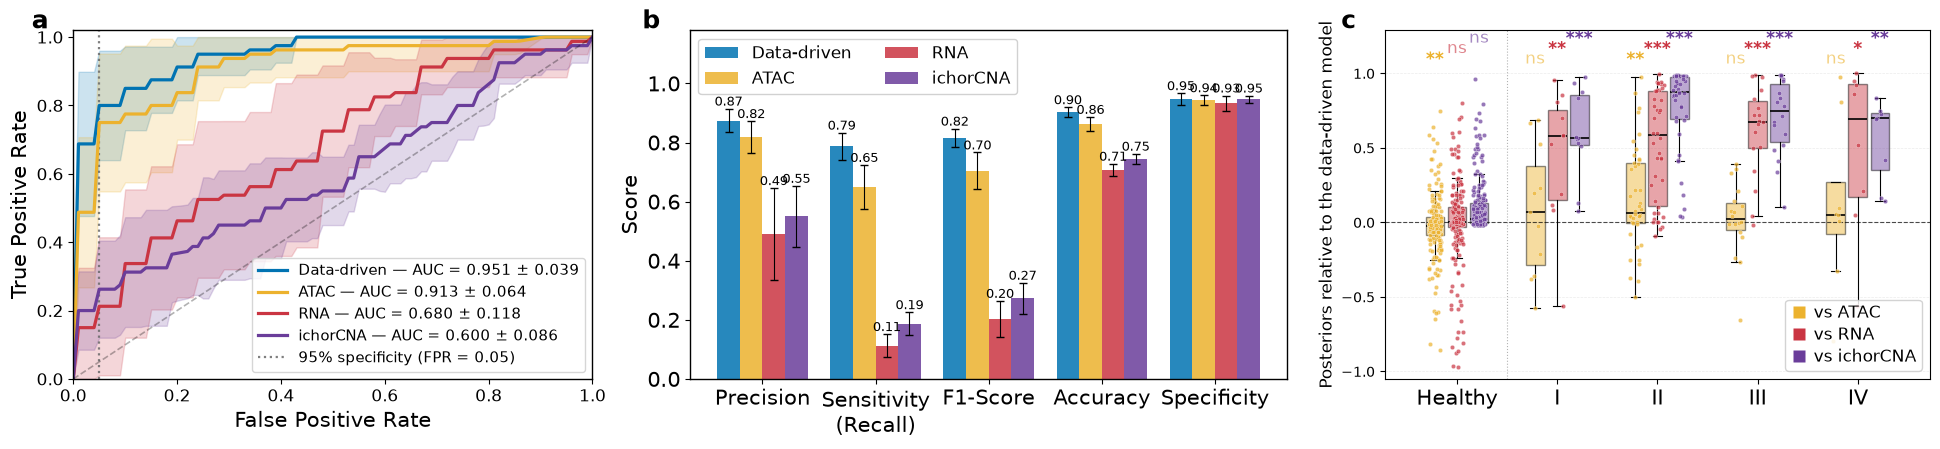

In [7]:
approach_metrics = {m: collect_fold_metrics(m) for m in METHOD_LABELS}

fig, (ax_a, ax_b, ax_c) = plt.subplots(
    1, 3, figsize=(19.5, 4.6), gridspec_kw={"width_ratios": [1.0, 1.15, 1.05]})
panel_a(ax_a)
panel_b(ax_b, approach_metrics, error_type="sem")
test_results = panel_c(ax_c)
for ax, letter in zip((ax_a, ax_b, ax_c), "abc"):
    ax.text(-0.08, 1.06, letter, transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")
plt.tight_layout()

import os
os.makedirs("output", exist_ok=True)
fig.savefig("output/fig3.png", dpi=300, bbox_inches="tight")
fig.savefig("output/fig3.pdf", bbox_inches="tight")
plt.show()

## Check against the submitted manuscript values

In [8]:
ref = {
    "data_driven": (0.951, 0.039), "atac": (0.913, 0.064),
    "rna": (0.680, 0.118), "ichorcna": (0.600, 0.086),
}
print("mean AUC over folds (computed vs manuscript Fig 3a legend):")
for method in ref:
    aucs = [a for _, _, a in fold_rocs(pred[(pred["method"] == method) & pred["fold"].notna()])]
    print(f"  {METHOD_LABELS[method]:<12} {np.mean(aucs):.3f} ± {np.std(aucs):.3f}   "
          f"(manuscript: {ref[method][0]:.3f} ± {ref[method][1]:.3f})")

print("\nData-driven metrics at 95% specificity (manuscript Fig 3b: "
      "0.87 / 0.79 / 0.82 / 0.90 / 0.95):")
m = approach_metrics["data_driven"]
print("  " + " / ".join(f"{np.mean(m[k]):.2f}" for k in
                        ["precision", "recall", "f1-score", "accuracy", "specificity"]))

print("\nPanel c directional Wilcoxon p-values:")
for (cat, comp), r in test_results.items():
    print(f"  {cat:<8} vs {comp:<9} n={r['n']:>3}  median diff={r['median']:+.3f}  "
          f"p={r['p_directional']:.2e} ({_sig_marker(r['p_directional'])})")

mean AUC over folds (computed vs manuscript Fig 3a legend):
  Data-driven  0.951 ± 0.039   (manuscript: 0.951 ± 0.039)
  ATAC         0.913 ± 0.064   (manuscript: 0.913 ± 0.064)
  RNA          0.680 ± 0.118   (manuscript: 0.680 ± 0.118)
  ichorCNA     0.600 ± 0.086   (manuscript: 0.600 ± 0.086)

Data-driven metrics at 95% specificity (manuscript Fig 3b: 0.87 / 0.79 / 0.82 / 0.90 / 0.95):
  0.87 / 0.79 / 0.82 / 0.90 / 0.95

Panel c directional Wilcoxon p-values:
  Healthy  vs ATAC      n=210  median diff=-0.021  p=2.89e-03 (**)
  Healthy  vs RNA       n=210  median diff=+0.005  p=9.71e-01 (ns)
  Healthy  vs ichorCNA  n=210  median diff=+0.023  p=1.00e+00 (ns)
  I        vs ATAC      n= 11  median diff=+0.069  p=3.19e-01 (ns)
  I        vs RNA       n= 11  median diff=+0.577  p=4.88e-03 (**)
  I        vs ichorCNA  n= 11  median diff=+0.570  p=4.88e-04 (***)
  II       vs ATAC      n= 42  median diff=+0.067  p=1.59e-03 (**)
  II       vs RNA       n= 42  median diff=+0.585  p=1.22e-10 (*